# 📊 CodeAlpha Task 3 — Data Visualization

## Superstore Sales Data Visualization and Business Insights

**Internship:** CodeAlpha Data Analytics Internship  
**Task:** Task 3 — Data Visualization  

### Objective

The objective of this project is to transform sales data into meaningful visualizations and identify patterns in sales, profit, products, categories, and regions.

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
url = "https://raw.githubusercontent.com/leonism/sample-superstore/master/data/superstore.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (10800, 21)


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (10800, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 5 Rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164



Data Types:
Row ID            object
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity         float64
Discount         float64
Profit           float64
dtype: object


In [4]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")

print(df["Order Date"].dtype)

datetime64[ns]


In [5]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
Row ID             0
Order ID           0
Order Date       806
Ship Date        806
Ship Mode        806
Customer ID      806
Customer Name    806
Segment          806
Country          806
City             806
State            806
Postal Code      817
Region           806
Product ID       806
Category         806
Sub-Category     806
Product Name     806
Sales            806
Quantity         806
Discount         806
Profit           806
dtype: int64

Duplicate rows: 504


In [6]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
average_order_value = df["Sales"].mean()

print("========== KEY PERFORMANCE INDICATORS ==========")

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Average Order Value: ${average_order_value:,.2f}")

========== KEY PERFORMANCE INDICATORS ==========
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Quantity Sold: 37,873.0
Average Order Value: $229.86


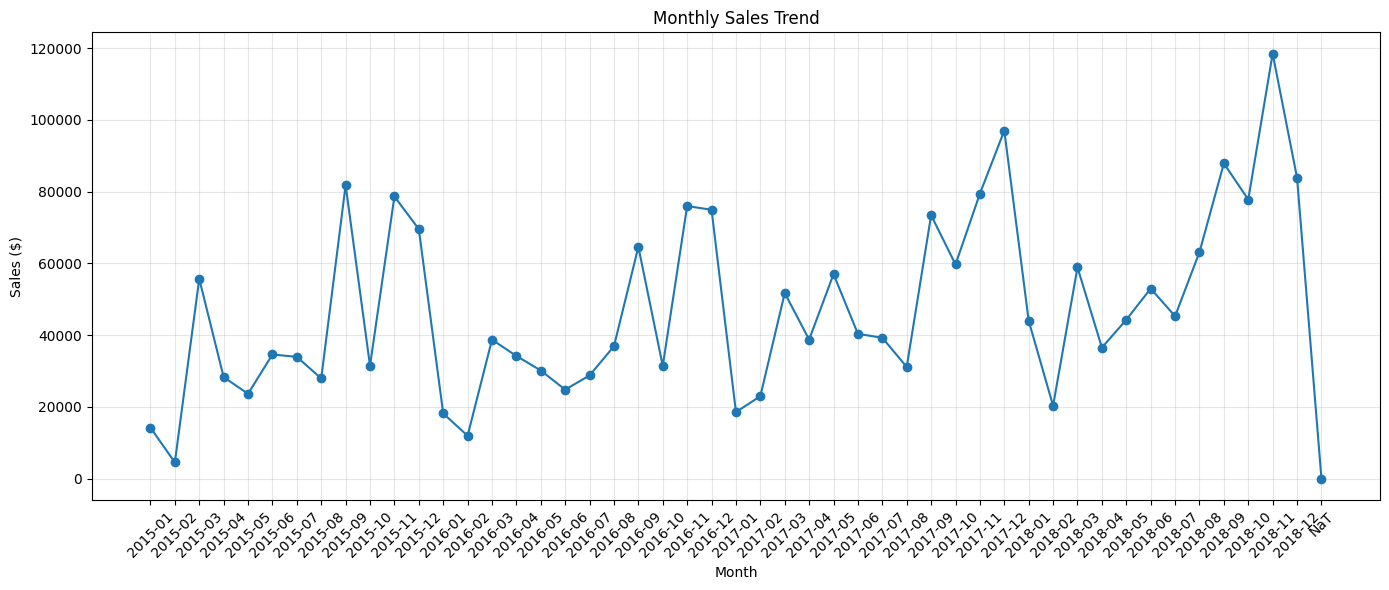

In [7]:
df["Month"] = df["Order Date"].dt.to_period("M").astype(str)

monthly_sales = df.groupby("Month")["Sales"].sum()

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

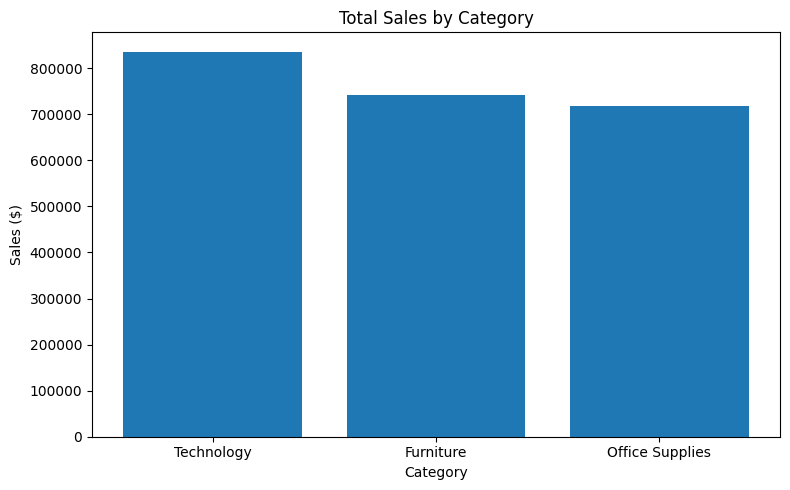

In [8]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    category_sales.index,
    category_sales.values
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales ($)")

plt.tight_layout()
plt.show()

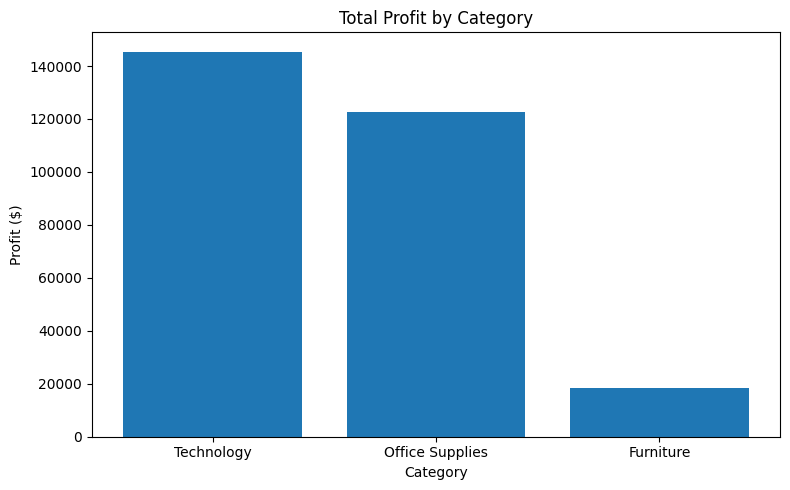

In [9]:
category_profit = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    category_profit.index,
    category_profit.values
)

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit ($)")

plt.tight_layout()
plt.show()

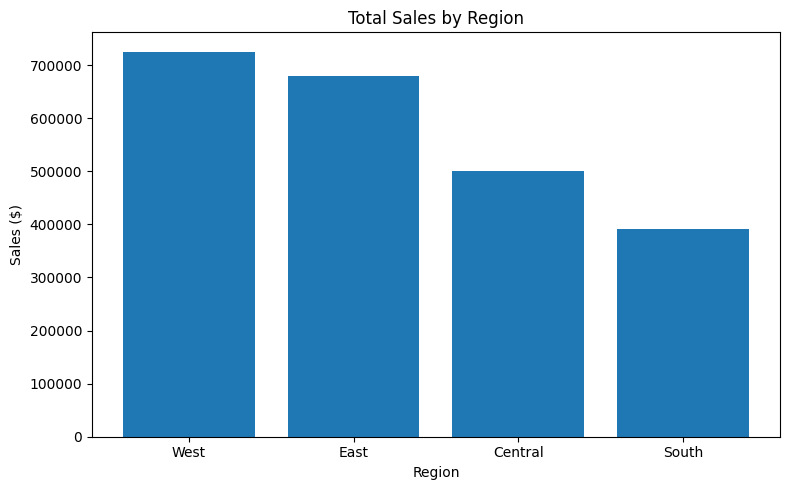

In [10]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    region_sales.index,
    region_sales.values
)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales ($)")

plt.tight_layout()
plt.show()

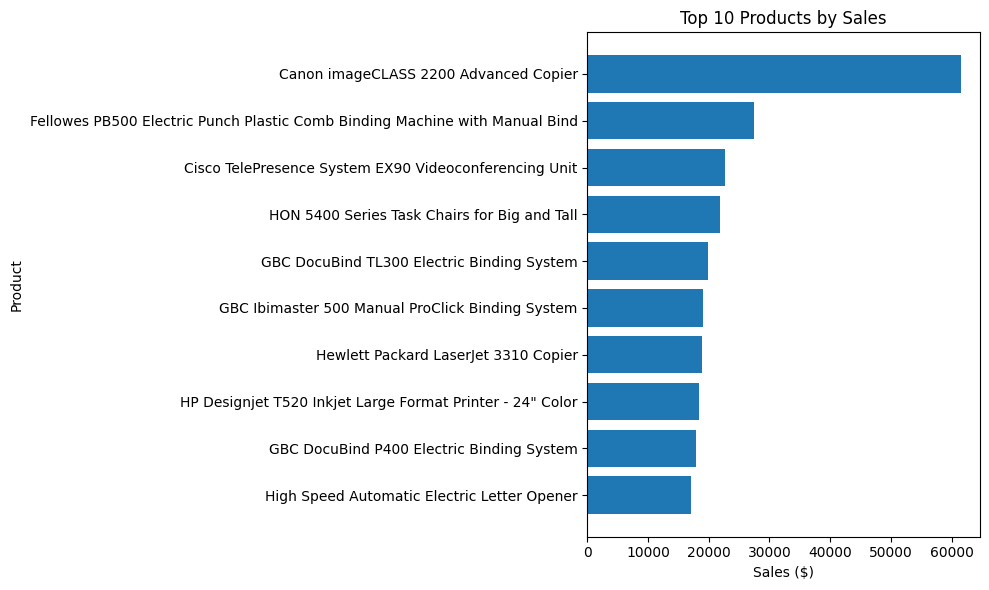

In [11]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_products.index,
    top_products.values
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales ($)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

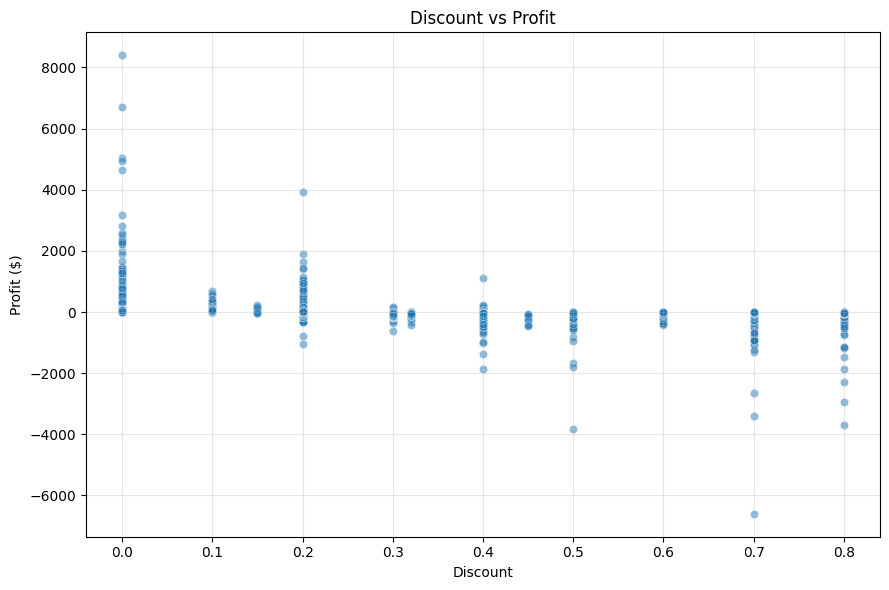

In [12]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    alpha=0.5
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit ($)")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

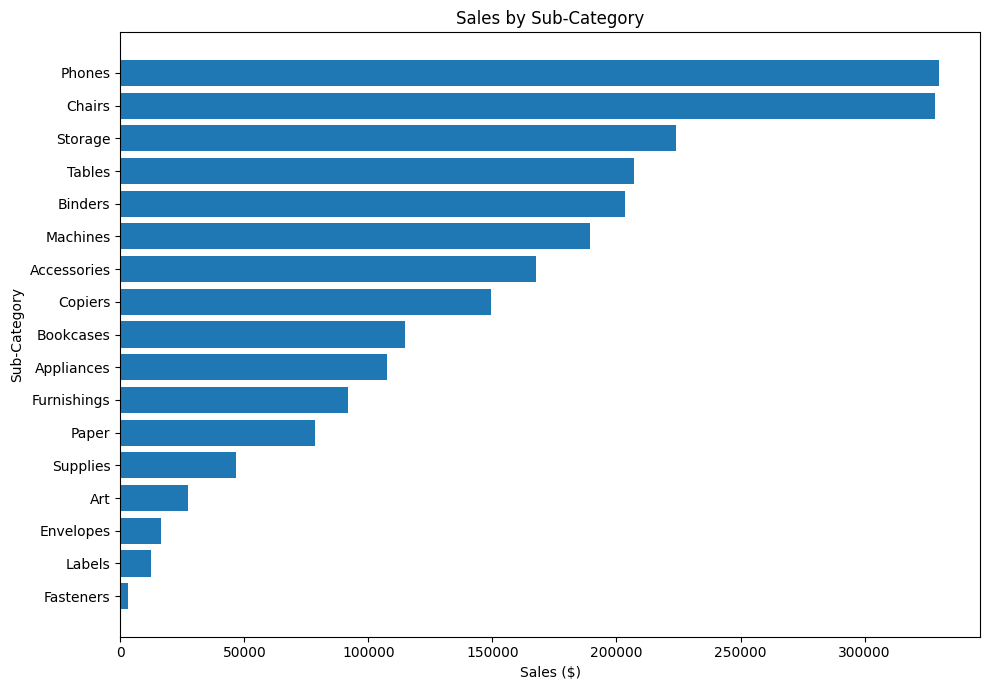

In [13]:
subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    subcategory_sales.index,
    subcategory_sales.values
)

plt.title("Sales by Sub-Category")
plt.xlabel("Sales ($)")
plt.ylabel("Sub-Category")

plt.tight_layout()
plt.show()

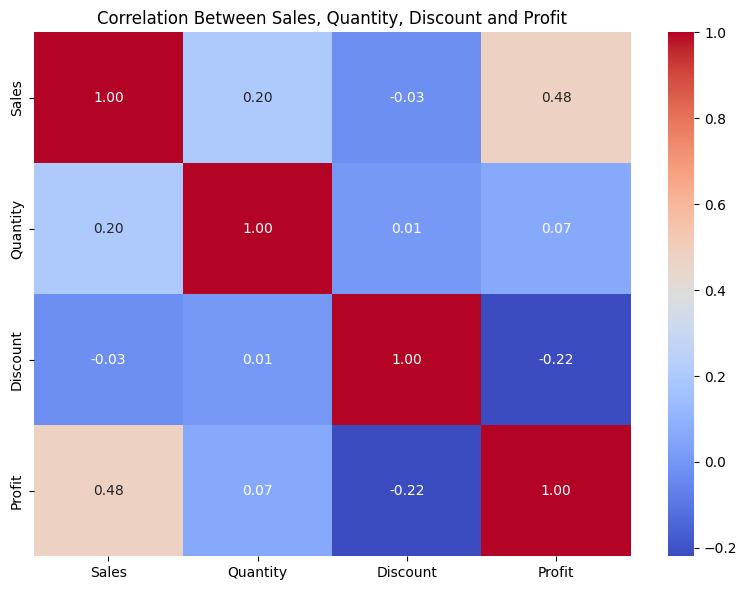

In [14]:
numeric_columns = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Sales, Quantity, Discount and Profit")

plt.tight_layout()
plt.show()

In [15]:
summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Total Quantity",
        "Average Order Value"
    ],
    "Value": [
        total_sales,
        total_profit,
        total_quantity,
        average_order_value
    ]
})

summary

,Metric,Value
0,Total Sales,2.297201e+06
1,Total Profit,2.863970e+05
2,Total Quantity,3.787300e+04
3,Average Order Value,2.298580e+02


In [16]:
print("========== KEY BUSINESS INSIGHTS ==========\n")

print(
    "Highest Sales Category:",
    category_sales.idxmax(),
    f"(${category_sales.max():,.2f})"
)

print(
    "Highest Profit Category:",
    category_profit.idxmax(),
    f"(${category_profit.max():,.2f})"
)

print(
    "Highest Sales Region:",
    region_sales.idxmax(),
    f"(${region_sales.max():,.2f})"
)

print(
    "Top Product by Sales:",
    top_products.idxmax(),
    f"(${top_products.max():,.2f})"
)

========== KEY BUSINESS INSIGHTS ==========

Highest Sales Category: Technology ($836,154.03)
Highest Profit Category: Technology ($145,454.95)
Highest Sales Region: West ($725,457.82)
Top Product by Sales: Canon imageCLASS 2200 Advanced Copier ($61,599.82)


# 📌 Key Insights

The visualization analysis provides an overview of sales and profitability across different business dimensions.

### Major observations

- The monthly sales chart shows how sales change over time.
- Category-level analysis allows comparison of sales and profit across product categories.
- Regional analysis shows differences in sales contribution across regions.
- The top-product analysis identifies products contributing substantially to total sales.
- The discount-versus-profit visualization helps examine the relationship between discounts and profitability.
- The sub-category visualization provides a more detailed view of product performance.
- The correlation heatmap summarizes relationships between major numerical variables.

### Conclusion

Data visualization makes it easier to identify trends, compare business segments, and communicate important patterns from the sales dataset. The combination of time-series, categorical, relational, and correlation visualizations provides a broader view of the dataset and supports data-driven interpretation.